# LINEAR REGRESSION 
LINEAR REGRESSION IS A WIDELY USED STATISTICAL TECHNIQUE FOR MODELING THE RELATIONSHIP BETWEEN A DEPENDENT VARIABLE AND ONE OR MORE INDEPENDENT VARIABLE. IT ASSUMES A LINEAR RELATIONSHIP BETWEEN A VARIABLES AND AIMS TO FIND THE BEST FIT LINE THAT MINIMIZES THE DIFFERENCE BETWEEN THE PREDICTED AND ACTUAL VALUE .THE GOAL OF LINEAR REGRESSION IS TO MAKE PREDICTIONS OR UNDERSTAND THE IMPACT OF INDEPENDENT VARIABLES ON THE DEPENDENT VARIABLES

y=mx+c
y is the dependent variable 
x is the independent variable 
c is the y-intercept(the value of y when x is 0 )
m is the slope (the change in y for a unit change in x )

# ASSUMPTION
https://www.geeksforgeeks.org/machine-learning/assumptions-of-linear-regression/

# Parameter Estimation Techniques
Now that you know the assumptions of Linear Regression, it's time you know the techniques to find the parameters, i.e., intercept and regression coefficients. Two of them are as follows:

Least Squares Estimation


In practice, observed data or input-output pair is given, and 
 are unknown. We use the given input-output pair to estimate the coefficients. The estimated intercept and regression coefficient later helps us in predicting the output value with the input values. There is an error or residual since the estimated regression can not satisfy all the output data points. Hence, we have an error or residual, which is the difference between the estimated output value and the actual output value. Errors can either be positive or negative. We can sum the errors to evaluate the estimated linear regression line. To get rid of the cancellation of the positive and negative error, we square the error and add then which is popularly called as Sum of Squares of errors or Residual Sum of Squares.

This parameter estimation technique finds the parameters by minimizing the sum of squares. There are mainly three types of Least Squares:

  - Ordinary Least Squares

  - Weighted Least Squares

  - Generalized Least Squares
Maximum Likelihood Estimation

Maximum likelihood estimation is a well known probabilistic framework for finding parameters that best describe the observed data. You find the parameters by maximizing the conditional probability of observing the data, 
 given specific probability distribution and its parameters 
. Detailed discussion on this technique is out of the scope.

In [14]:
# implementation 
import pandas as pd 
import numpy as np 
data_df=pd.read_csv("advertising .csv",index_col=0)
data_df


,TV,radio,newspaper,sales
1,230.1,37.8,69.2,22.1
2,44.5,39.3,45.1,10.4
3,17.2,45.9,69.3,9.3
4,151.5,41.3,58.5,18.5
5,180.8,10.8,58.4,12.9
...,...,...,...,...
196,38.2,3.7,13.8,7.6
197,94.2,4.9,8.1,9.7
198,177.0,9.3,6.4,12.8
199,283.6,42.0,66.2,25.5


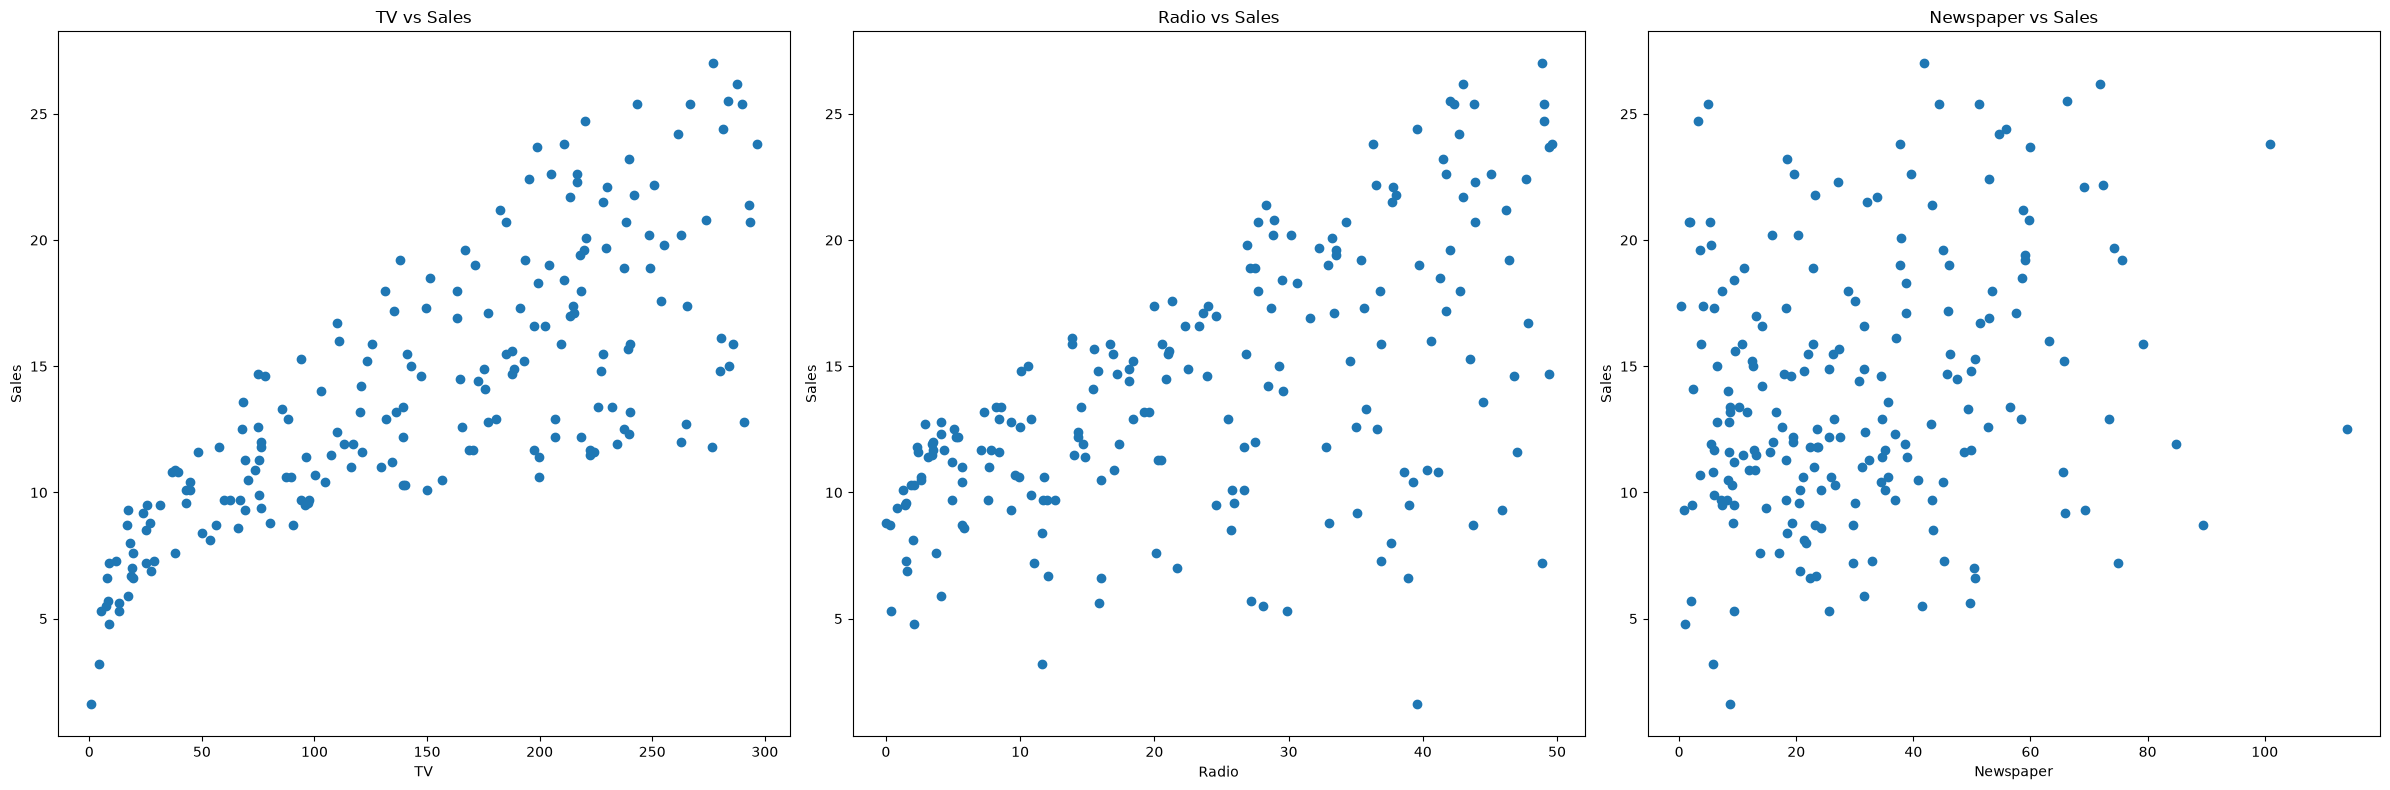

In [18]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(24, 8))

axes[0].scatter(data_df["TV"], data_df["sales"])
axes[0].set_xlabel("TV")
axes[0].set_ylabel("Sales")
axes[0].set_title("TV vs Sales")

axes[1].scatter(data_df["radio"], data_df["sales"])
axes[1].set_xlabel("Radio")
axes[1].set_ylabel("Sales")
axes[1].set_title("Radio vs Sales")

axes[2].scatter(data_df["newspaper"], data_df["sales"])
axes[2].set_xlabel("Newspaper")
axes[2].set_ylabel("Sales")
axes[2].set_title("Newspaper vs Sales")

plt.tight_layout()
plt.show()

In [19]:
data_df.corr()

,TV,radio,newspaper,sales
TV,1.000000,0.054809,0.056648,0.782224
radio,0.054809,1.000000,0.354104,0.576223
newspaper,0.056648,0.354104,1.000000,0.228299
sales,0.782224,0.576223,0.228299,1.000000


In [21]:
x=data_df.TV.to_numpy()
y=data_df.sales.to_numpy()

In [23]:
x_mean=x.mean()
y_mean=y.mean()
beta_1=np.sum((x-x_mean)*(y-y_mean))/np.sum(np.power((x-x_mean),2))

In [25]:
beta_0=y_mean-(beta_1*x_mean)

In [26]:
print(f"y={beta_0:.2f}+{beta_1:.2f}x")

y=7.03+0.05x


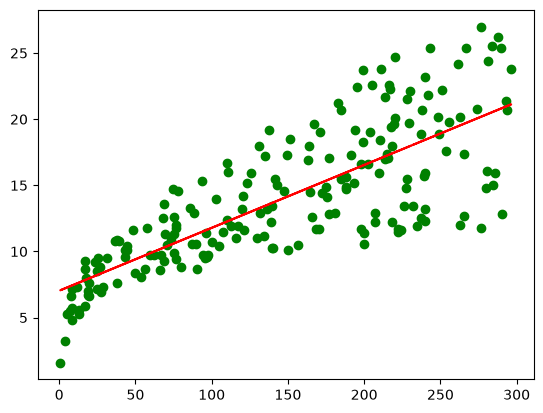

In [30]:
import matplotlib.pyplot as plot
plot.scatter(x,y,color="green")
plot.plot(x,beta_0+(beta_1*x),color="red")

In [ ]:
#predicted value
y_cap=beta_0+(beta_1*x)

In [35]:
#lowest point of error according to beta_0 and beta_1
sse=np.sum(np.power((y-y_cap),2))
sse

np.float64(2102.5305831313512)

In [39]:
# maile tv ma 500 lagai bhani sales kati auxa ???
y_cap=beta_0+(beta_1*500)
y_cap

np.float64(30.800913765637564)

In [40]:
from sklearn.linear_model import LinearRegression

In [45]:
linear_reg=LinearRegression()
linear_reg.fit(x.reshape(-1,1),y.reshape(-1,1))

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1, 1)",[[0.05]]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](1,)",[7.03]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[1211.12]


In [46]:
linear_reg.coef_

array([[0.04753664]])

In [47]:
linear_reg.intercept_

array([7.03259355])

In [49]:
y_cap=linear_reg.predict(x.reshape(-1,1))
y_cap

array([[17.97077451],
       [ 9.14797405],
       [ 7.85022376],
       [14.23439457],
       [15.62721814],
       [ 7.44616232],
       [ 9.76595037],
       [12.74649773],
       [ 7.44140866],
       [16.53041431],
       [10.17476548],
       [17.23871025],
       [ 8.16396559],
       [11.66741599],
       [16.73482186],
       [16.32125309],
       [10.25557777],
       [20.40940417],
       [10.32212907],
       [14.03474068],
       [17.41459582],
       [18.31779199],
       [ 7.6600772 ],
       [17.88520856],
       [ 9.99412625],
       [19.52997632],
       [13.82557947],
       [18.44614092],
       [18.85970969],
       [10.38868036],
       [20.95607553],
       [12.39948025],
       [11.653155  ],
       [19.65832525],
       [11.58185004],
       [20.85149492],
       [19.72012288],
       [10.58358059],
       [ 9.08142275],
       [17.87094757],
       [16.65876324],
       [15.44657891],
       [20.98935118],
       [16.86792445],
       [ 8.22576322],
       [15

In [53]:
sse=np.sum((y-y_cap.flatten())**2)
sse

np.float64(2102.5305831313512)